In [14]:
import gc
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip(line, cell):
    return

In [15]:
# showing table schema and creating path variables
import duckdb

# PARQUET FILES ARE FROM https://huggingface.co/datasets/SII-WANGZJ/Polymarket_data BIG THANK YOU FOR ALL THE DATA
# Note I made a new User file to add if a users trade won or not in DBshenanigans.py to make everything easier for training (the win rate is about 49.91%)

tradesPQ = 'X:/PolymarketData/trades.parquet'
marketPQ = 'X:/PolymarketData/markets.parquet'
usersPQ = 'X:/PolymarketData/Users2.parquet'
print("User Schema:")
print(duckdb.query(f" SELECT * FROM '{usersPQ}' LIMIT 1"))
print("Trade Schema:")
print(duckdb.query(f" SELECT * FROM '{tradesPQ}' LIMIT 1"))
print("Market Schema:")
print(duckdb.query(f" SELECT * FROM '{marketPQ}' LIMIT 1"))

User Schema:
┌────────────┬──────────────┬──────────────────────────────────────────────────────────────────┬───────────┬────────────────────────────────────────────┬─────────┬───────────┬────────────┬──────────────┬────────┬───────────┬────────────────────────────────────────────────────────────────────┬──────────┬──────────────┬─────────┐
│ timestamp  │ block_number │                         transaction_hash                         │ log_index │                  address                   │  role   │ direction │ usd_amount │ token_amount │ price  │ market_id │                            condition_id                            │ event_id │ nonusdc_side │   won   │
│   uint64   │    uint64    │                             varchar                              │  uint32   │                  varchar                   │ varchar │  varchar  │   double   │    double    │ double │  varchar  │                              varchar                               │ varchar  │   varchar    │ boolean

In [1]:
import pandas as pd
#userdf = duckdb.query(f"SELECT address, COUNT(*) AS nTrades, COUNT(DISTINCT market_id) as nMarkets, AVG(CAST(won AS INTEGER)) AS win_rate, AVG(usd_amount) as avg_spent, SUM(usd_amount) as total_spent, MAX(usd_amount) as max_spent, AVG(price) as avg_price FROM '{usersPQ}' GROUP BY address HAVING COUNT(*) > 15 LIMIT 200000").to_df()
userdf = pd.read_parquet('UserDf.parquet')

<Axes: >

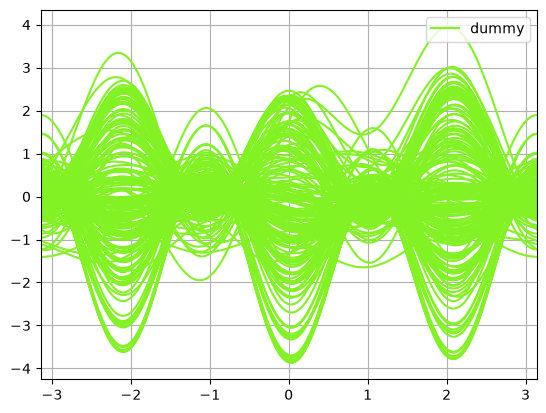

In [2]:


rest = userdf.columns.difference(["address","dummy"])
normdf = (userdf[rest] - userdf[rest].mean())/userdf[rest].std()
normdf["dummy"] = "dummy"
sampledf = normdf.sample(200,random_state=42)
pd.plotting.andrews_curves(sampledf, 'dummy')

In [28]:
%%skip
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

k=13
sampledf=normdf[normdf.columns.difference(["dummy"])]
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(sampledf)
distances, indices = neighbors_fit.kneighbors(sampledf)

# 3. Sort distances by the max (k-th) neighbor distance
sorted_distances = np.sort(distances[:, k-1], axis=0)

# 4. Plot the graph
plt.figure(figsize=(8, 5))
plt.axis([0, 200000, 0, 1])
plt.plot(sorted_distances, color='royalblue', lw=2)
plt.title(f'{k}-th Nearest Neighbor Distance Graph', fontsize=14)
plt.xlabel('Data Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'Distance to {k}-th Neighbor', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [4]:

import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=700,min_samples=5, prediction_data=True)
cats = labels = clusterer.fit_predict(normdf[rest])
userdf['category'] = cats
normdf['category'] = cats

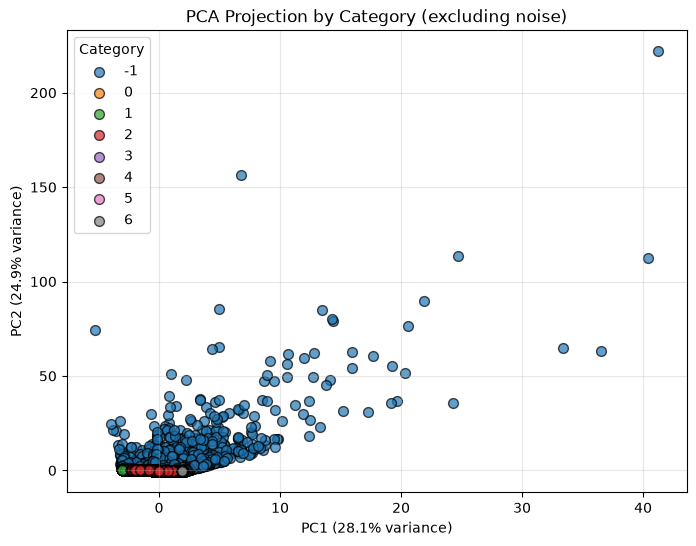

In [7]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
np.random.seed(42)

pca = PCA(n_components=2)
transformed_data = pca.fit_transform(normdf[rest])  

mask_valid = ~userdf['category'].isin([])
labels_filtered = userdf.loc[mask_valid, 'category'].values
data_filtered = transformed_data[mask_valid.values]

unique_labels = np.unique(labels_filtered)

plt.figure(figsize=(8, 6))
for label in unique_labels:
    mask = labels_filtered == label
    plt.scatter(
        data_filtered[mask, 0],
        data_filtered[mask, 1],
        label=str(label),
        alpha=0.7,
        edgecolor='k',
        s=50
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Projection by Category (excluding noise)")
plt.legend(title="Category")
plt.grid(True, alpha=0.3)
plt.show()

<Axes: >

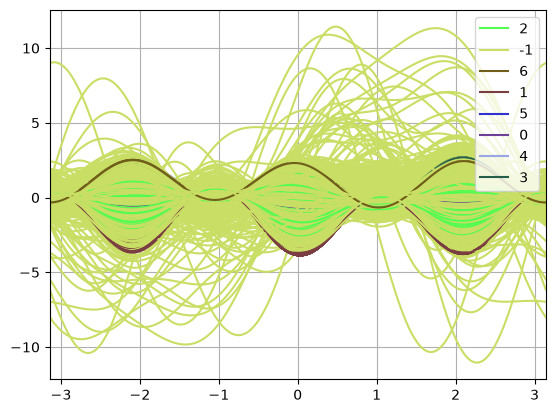

In [6]:
pd.plotting.andrews_curves(normdf[normdf.columns.difference(["dummy"])].sample(2000), 'category')

In [9]:
print (userdf.category.value_counts())
sampledf = userdf.drop_duplicates(subset=['category'])
print(sampledf)

category
-1    145200
 2     37328
 1      8232
 6      4347
 5      1902
 4      1218
 3       942
 0       831
Name: count, dtype: int64
                                         address  nTrades  nMarkets  win_rate  \
0     0xc4cd61d921d8ea3ac75d71bf87b26523954e7d22      164         6  0.932927   
4     0xa79af3bab636f41f1f7bd1c568857dbdf4650beb       25         4  0.320000   
12    0x00f6b808ca16327ed16dd8753a3a375b79235231       23        10  0.000000   
267   0xed3c2cbe2b3870a7aa6c7602995506eed6104cf2       40         6  0.600000   
546   0xa09491fed426adb6aba2127c4d2fded587ee8ea5       78        13  1.000000   
695   0xbba50e2888c69ab6e140db7ef89b5e1af4773533       34        12  1.000000   
1086  0xd63d9568eb23e3f02af5157f892e4cd3c9187a9f       93        55  1.000000   
1098  0x7bfcc859023e6542b30bee648429439bb14cb609       58        18  1.000000   

       avg_spent   total_spent  max_spent  avg_price  category  
0     188.135183  30854.169999    4974.00   0.531254        -1  
4

In [23]:
for column in rest:
    print(column)
    print("-"*20)
    print(userdf.groupby("category")[column].describe())

avg_price
--------------------
             count      mean       std       min       25%       50%  \
category                                                               
-1        145200.0  0.638682  0.247213  0.001000  0.474422  0.620853   
 0           831.0  0.537804  0.015463  0.499714  0.526979  0.536932   
 1          8232.0  0.030522  0.049360  0.001000  0.005875  0.006818   
 2         37328.0  0.544766  0.150653  0.157988  0.458359  0.530780   
 3           942.0  0.992846  0.002123  0.984991  0.992187  0.993254   
 4          1218.0  0.997016  0.001704  0.989333  0.996140  0.997337   
 5          1902.0  0.994384  0.001041  0.991048  0.993694  0.994667   
 6          4347.0  0.992799  0.002402  0.981750  0.991750  0.992967   

               75%       max  
category                      
-1        0.865812  0.999000  
 0        0.548602  0.585744  
 1        0.023475  0.244025  
 2        0.628165  0.972989  
 3        0.993983  0.998375  
 4        0.998655  0.998937  


In [24]:
userdf.to_parquet("userCatsDf.parquet")

In [ ]:
%%skip
import joblib

joblib.dump(clusterer, 'hdbscan_model.pkl')

['hdbscan_model.pkl']